In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
df = pd.read_csv("../data/transactions.csv")
df.head()

,id,user_id,amount,description,category,is_want,created_at,date,payment_mode
0,1,1,26230,Exam Fee,Fees,False,2026-07-05 14:42:47.485172,2026-04-05,Cash
1,2,1,264,Bus Pass,Transport,False,2026-07-05 14:42:47.485227,2026-02-14,Cash
2,3,1,944,Concert Ticket,Entertainment,True,2026-07-05 14:42:47.485272,2026-05-25,Cash
3,4,1,206,Coffee,Food,True,2026-07-05 14:42:47.485300,2026-01-08,Card
4,5,1,1406,Clothes,Shopping,True,2026-07-05 14:42:47.485324,2026-01-11,Card


In [5]:
df.shape

(35348, 9)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35348 entries, 0 to 35347
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            35348 non-null  int64 
 1   user_id       35348 non-null  int64 
 2   amount        35348 non-null  int64 
 3   description   35348 non-null  object
 4   category      35348 non-null  object
 5   is_want       35348 non-null  bool  
 6   created_at    35348 non-null  object
 7   date          35348 non-null  object
 8   payment_mode  35348 non-null  object
dtypes: bool(1), int64(3), object(5)
memory usage: 2.2+ MB


In [9]:
df.describe()

,id,user_id,amount
count,35348.000000,35348.000000,35348.000000
mean,17674.500000,999.243748,5506.656190
std,10204.232994,577.056857,10844.203648
min,1.000000,1.000000,20.000000
25%,8837.750000,501.000000,262.000000
50%,17674.500000,995.000000,971.500000
75%,26511.250000,1497.000000,4357.000000
max,35348.000000,2000.000000,49998.000000


In [12]:
df.columns.tolist()

['id',
 'user_id',
 'amount',
 'description',
 'category',
 'is_want',
 'created_at',
 'date',
 'payment_mode']

In [13]:
df.isnull().sum()

id              0
user_id         0
amount          0
description     0
category        0
is_want         0
created_at      0
date            0
payment_mode    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["is_want"].value_counts()

is_want
False    18788
True     16560
Name: count, dtype: int64

In [16]:
df["category"].value_counts()

category
Shopping         5953
Food             5942
Fees             5911
Transport        5860
Books            5851
Entertainment    5831
Name: count, dtype: int64

In [17]:
df["payment_mode"].value_counts()

payment_mode
UPI     24843
Card     7002
Cash     3503
Name: count, dtype: int64

In [18]:
df["amount"].sum()

np.int64(194649283)

In [19]:
df["amount"].max()

49998

In [25]:
df.loc[df['amount'] == df['amount'].max(), 'user_id'].values[0]

np.int64(1130)

In [26]:
df.loc[df["amount"].idxmax()]

id                                   20087
user_id                               1130
amount                               49998
description                       Exam Fee
category                              Fees
is_want                              False
created_at      2026-07-05 14:42:47.693133
date                            2026-04-14
payment_mode                           UPI
Name: 20086, dtype: object

In [27]:
df["amount"].min()

20

In [28]:
df["amount"].mean()

np.float64(5506.656189883444)

In [29]:
df["amount"].median()

971.5

In [30]:
df.groupby("category")["amount"].mean()

category
Books             1041.748077
Entertainment     1058.802950
Fees             25314.400102
Food               275.664086
Shopping          5068.387872
Transport          159.830546
Name: amount, dtype: float64

In [31]:
df.groupby("payment_mode")["amount"].mean()

payment_mode
Card    5328.562268
Cash    5798.661148
UPI     5515.677656
Name: amount, dtype: float64

In [32]:
df.groupby("is_want")["amount"].mean()

is_want
False    8363.422025
True     2265.538043
Name: amount, dtype: float64

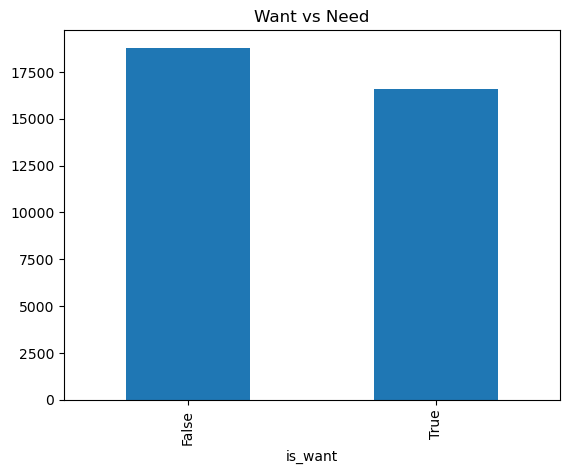

In [33]:
df["is_want"].value_counts().plot(kind="bar")
plt.title("Want vs Need")
plt.show()

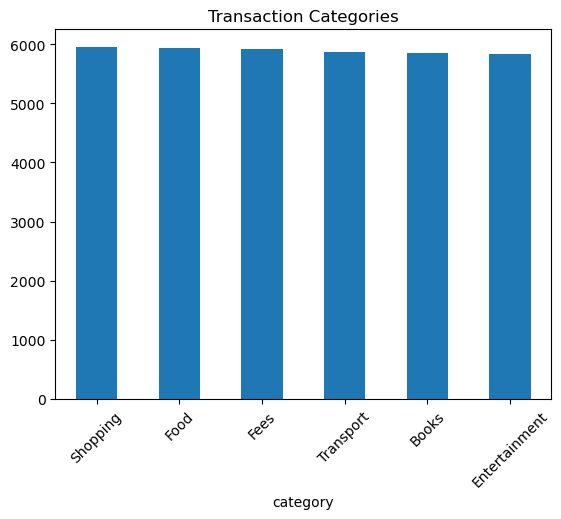

In [34]:
df["category"].value_counts().plot(kind="bar")
plt.title("Transaction Categories")
plt.xticks(rotation=45)
plt.show()

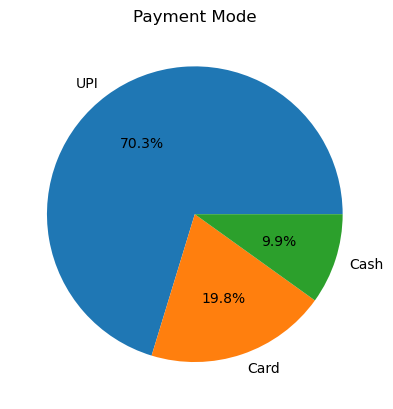

In [35]:
df["payment_mode"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Mode")
plt.ylabel("")
plt.show()

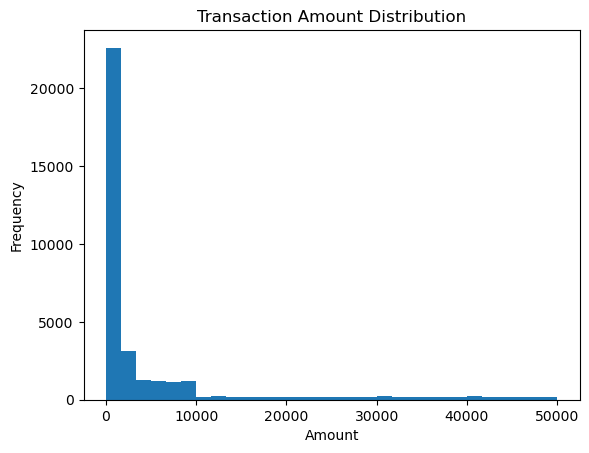

In [36]:
plt.hist(df["amount"], bins=30)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()